In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os


### Baseline graphs

In [2]:
baseline_folder = 'Baseline'

dfs = []

for filename in os.listdir(baseline_folder):
    filepath = os.path.join(baseline_folder, filename)
    df = pd.read_csv(filepath)
    df["source_file"] = filename
    dfs.append(df)

baseline_df = pd.concat(dfs, ignore_index=True)
baseline_df.shape

(1000, 20)

In [3]:
# Guess graph - baseline
bl_guess_accuracy = {}

for i in range(1, 6):
    guess_col = f"guess{i}"
    
    if guess_col in baseline_df.columns:
        valid = baseline_df[
            baseline_df[guess_col].notna() &
            (baseline_df[guess_col] != "") &
            (baseline_df[guess_col] != "NAN")
        ]
        
        if len(valid) > 0:
            percent = (valid[guess_col] == valid["solution"]).mean() * 100
        else:
            percent = 0
        
        bl_guess_accuracy[f"Guess {i}"] = percent

bl_guess_accuracy

{'Guess 1': np.float64(54.769230769230774),
 'Guess 2': np.float64(17.491749174917494),
 'Guess 3': np.float64(13.972602739726028),
 'Guess 4': np.float64(8.754208754208754),
 'Guess 5': np.float64(10.85972850678733)}

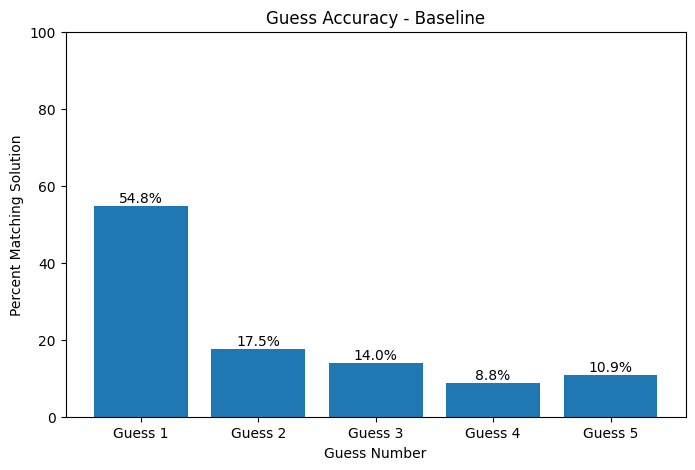

In [4]:
bl_accuracy_df = pd.DataFrame({
    "Guess": list(bl_guess_accuracy.keys()),
    "Percent Match": list(bl_guess_accuracy.values())
})

plt.figure(figsize=(8, 5))
plt.bar(bl_accuracy_df["Guess"], bl_accuracy_df["Percent Match"])
plt.xlabel("Guess Number")
plt.ylabel("Percent Matching Solution")
plt.title("Guess Accuracy - Baseline")
plt.ylim(0, 100)

for i, v in enumerate(bl_accuracy_df["Percent Match"]):
    plt.text(i, v + 1, f"{v:.1f}%", ha="center")

plt.show()

In [5]:
# confidence graph - baseline
for i in range(1, 6):
    guess_col = f"guess{i}"
    conf_col = f"confidence{i}"
    
    if guess_col in baseline_df.columns and conf_col in baseline_df.columns:
        baseline_df[f"correct{i}"] = (
            baseline_df[guess_col] == baseline_df["solution"]
        )

In [56]:
rows = []

for i in range(1, 6):
    guess_col = f"guess{i}"
    conf_col = f"confidence{i}"
    correct_col = f"correct1"
    
    if guess_col in baseline_df.columns:
        temp = baseline_df[[guess_col, conf_col, correct_col]].copy()
        temp.columns = ["guess", "confidence", "correct"]
        temp["guess_rank"] = i
        rows.append(temp)

baseline_confidence_df = pd.concat(rows, ignore_index=True)

In [57]:
baseline_confidence_df["confidence_range"] = pd.cut(baseline_confidence_df["confidence"], bins=[0,20,40,60,80,100])

bl_confidence_ranges = baseline_confidence_df.groupby("confidence_range")["correct"].mean() * 100

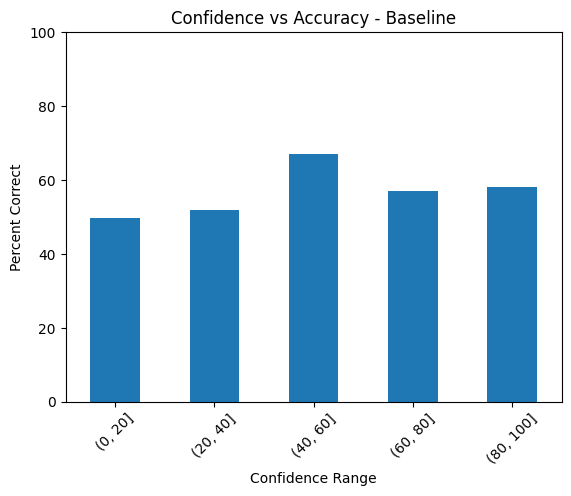

In [58]:
bl_confidence_ranges.plot(kind="bar")

plt.xlabel("Confidence Range")
plt.ylabel("Percent Correct")
plt.title("Confidence vs Accuracy - Baseline")
plt.xticks(rotation=45)
plt.ylim(0, 100)

plt.show()

### Self Consistency

In [9]:
sc_folder = 'Self-Consistency'

dfs = []

for filename in os.listdir(sc_folder):
    filepath = os.path.join(sc_folder, filename)
    df = pd.read_csv(filepath)
    df["source_file"] = filename
    dfs.append(df)

sc_df = pd.concat(dfs, ignore_index=True)
sc_df.shape

(1000, 20)

In [10]:
# Guess graph - self consistency
sc_guess_accuracy = {}

for i in range(1, 6):
    guess_col = f"guess{i}"
    
    if guess_col in sc_df.columns:
        valid = sc_df[
            sc_df[guess_col].notna() &
            (sc_df[guess_col] != "") &
            (sc_df[guess_col] != "NAN")
        ]
        
        if len(valid) > 0:
            percent = (valid[guess_col] == valid["solution"]).mean() * 100
        else:
            percent = 0
        
        sc_guess_accuracy[f"Guess {i}"] = percent

sc_guess_accuracy

{'Guess 1': np.float64(54.03225806451613),
 'Guess 2': np.float64(9.338929695697797),
 'Guess 3': np.float64(4.685714285714285),
 'Guess 4': np.float64(3.501945525291829),
 'Guess 5': np.float64(1.5432098765432098)}

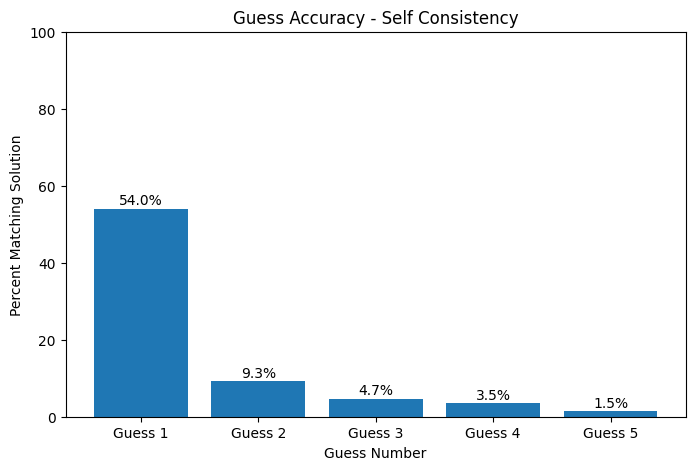

In [11]:
sc_accuracy_df = pd.DataFrame({
    "Guess": list(sc_guess_accuracy.keys()),
    "Percent Match": list(sc_guess_accuracy.values())
})

plt.figure(figsize=(8, 5))
plt.bar(sc_accuracy_df["Guess"], sc_accuracy_df["Percent Match"])
plt.xlabel("Guess Number")
plt.ylabel("Percent Matching Solution")
plt.title("Guess Accuracy - Self Consistency")
plt.ylim(0, 100)

for i, v in enumerate(sc_accuracy_df["Percent Match"]):
    plt.text(i, v + 1, f"{v:.1f}%", ha="center")

plt.show()

In [13]:
# confidence graph - self consistency
for i in range(1, 6):
    guess_col = f"guess{i}"
    conf_col = f"confidence{i}"
    
    if guess_col in sc_df.columns and conf_col in sc_df.columns:
        sc_df[f"correct{i}"] = (
            sc_df[guess_col] == sc_df["solution"]
        )

In [14]:
rows = []

for i in range(1, 6):
    guess_col = f"guess{i}"
    conf_col = f"confidence{i}"
    correct_col = f"correct{i}"
    
    if guess_col in sc_df.columns:
        temp = sc_df[[guess_col, conf_col, correct_col]].copy()
        temp.columns = ["guess", "confidence", "correct"]
        temp["guess_rank"] = i
        rows.append(temp)

sc_confidence_df = pd.concat(rows, ignore_index=True)

In [ ]:
sc_confidence_df["confidence_range"] = pd.cut(sc_confidence_df["confidence"], bins=[0,20,40,60,80,100])

sc_confidence_ranges = sc_confidence_df.groupby("confidence_range")["correct"].mean() * 100

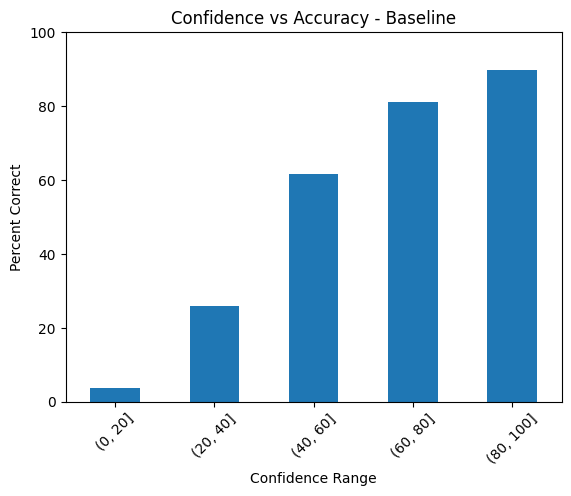

In [16]:
sc_confidence_ranges.plot(kind="bar")

plt.xlabel("Confidence Range")
plt.ylabel("Percent Correct")
plt.title("Confidence vs Accuracy - Baseline")
plt.xticks(rotation=45)
plt.ylim(0, 100)

plt.show()

### Self Consistency with Suggestions

In [17]:
sg_folder = 'Self-Consistency-and-Suggestions'

dfs = []

for filename in os.listdir(sg_folder):
    filepath = os.path.join(sg_folder, filename)
    df = pd.read_csv(filepath)
    df["source_file"] = filename
    dfs.append(df)

sg_df = pd.concat(dfs, ignore_index=True)
sg_df.shape

(600, 20)

In [20]:
# Guess graph - self consistency with suggestions
sg_guess_accuracy = {}

for i in range(1, 6):
    guess_col = f"guess{i}"
    
    if guess_col in sg_df.columns:
        valid = sg_df[
            sg_df[guess_col].notna() &
            (sg_df[guess_col] != "") &
            (sg_df[guess_col] != "NAN")
        ]
        
        if len(valid) > 0:
            percent = (valid[guess_col] == valid["solution"]).mean() * 100
        else:
            percent = 0
        
        sg_guess_accuracy[f"Guess {i}"] = percent

sg_guess_accuracy

{'Guess 1': np.float64(73.7458193979933),
 'Guess 2': np.float64(7.773851590106007),
 'Guess 3': np.float64(3.579952267303103),
 'Guess 4': np.float64(1.7421602787456445),
 'Guess 5': np.float64(1.9607843137254901)}

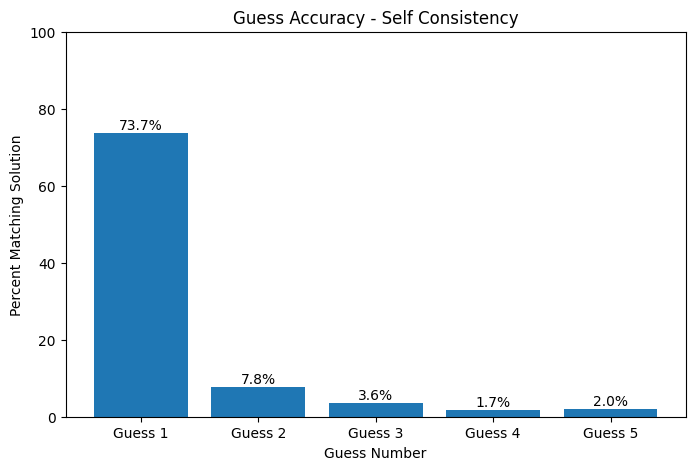

In [19]:
sg_accuracy_df = pd.DataFrame({
    "Guess": list(sg_guess_accuracy.keys()),
    "Percent Match": list(sg_guess_accuracy.values())
})

plt.figure(figsize=(8, 5))
plt.bar(sg_accuracy_df["Guess"], sg_accuracy_df["Percent Match"])
plt.xlabel("Guess Number")
plt.ylabel("Percent Matching Solution")
plt.title("Guess Accuracy - Self Consistency")
plt.ylim(0, 100)

for i, v in enumerate(sg_accuracy_df["Percent Match"]):
    plt.text(i, v + 1, f"{v:.1f}%", ha="center")

plt.show()

In [21]:
# confidence graph - self consistency with suggestions
for i in range(1, 6):
    guess_col = f"guess{i}"
    conf_col = f"confidence{i}"
    
    if guess_col in sg_df.columns and conf_col in sg_df.columns:
        sg_df[f"correct{i}"] = (
            sg_df[guess_col] == sg_df["solution"]
        )

In [22]:
rows = []

for i in range(1, 6):
    guess_col = f"guess{i}"
    conf_col = f"confidence{i}"
    correct_col = f"correct{i}"
    
    if guess_col in sg_df.columns:
        temp = sg_df[[guess_col, conf_col, correct_col]].copy()
        temp.columns = ["guess", "confidence", "correct"]
        temp["guess_rank"] = i
        rows.append(temp)

sg_confidence_df = pd.concat(rows, ignore_index=True)

In [ ]:
sg_confidence_df["confidence_range"] = pd.cut(sg_confidence_df["confidence"], bins=[0,20,40,60,80,100])

sg_confidence_ranges = sg_confidence_df.groupby("confidence_range")["correct"].mean() * 100

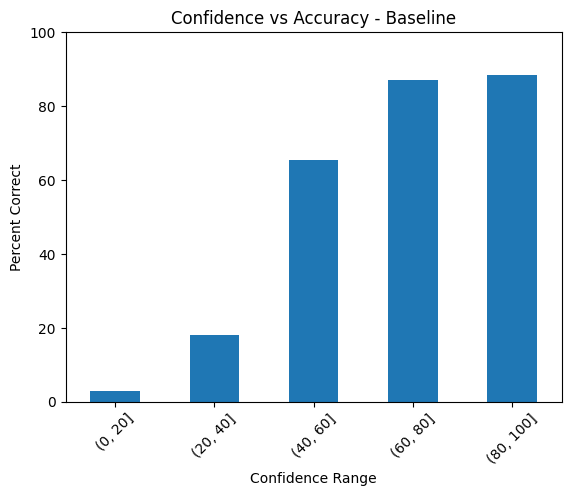

In [24]:
sg_confidence_ranges.plot(kind="bar")

plt.xlabel("Confidence Range")
plt.ylabel("Percent Correct")
plt.title("Confidence vs Accuracy - Baseline")
plt.xticks(rotation=45)
plt.ylim(0, 100)

plt.show()

### All data - confidence vs accuracy for all methods

In [42]:
baseline_df["method"] = "Baseline"
sc_df["method"] = "Self Consistency"
sg_df["method"] = "Self Consistency and Suggestions"

all_df = pd.concat([baseline_df, sc_df, sg_df], ignore_index=True)
all_df["correct1"] = (all_df["guess1"] == all_df["solution"])
all_df["confidence_ranges"] = pd.cut(all_df["confidence1"], bins=[0, 20, 40, 60, 80, 100])

In [43]:
confidence_ranges = (
    all_df
    .groupby(["method", "confidence_ranges"])["correct1"]
    .mean()
    .reset_index()
)
confidence_ranges["accuracy_percent"] = confidence_ranges["correct1"] * 100

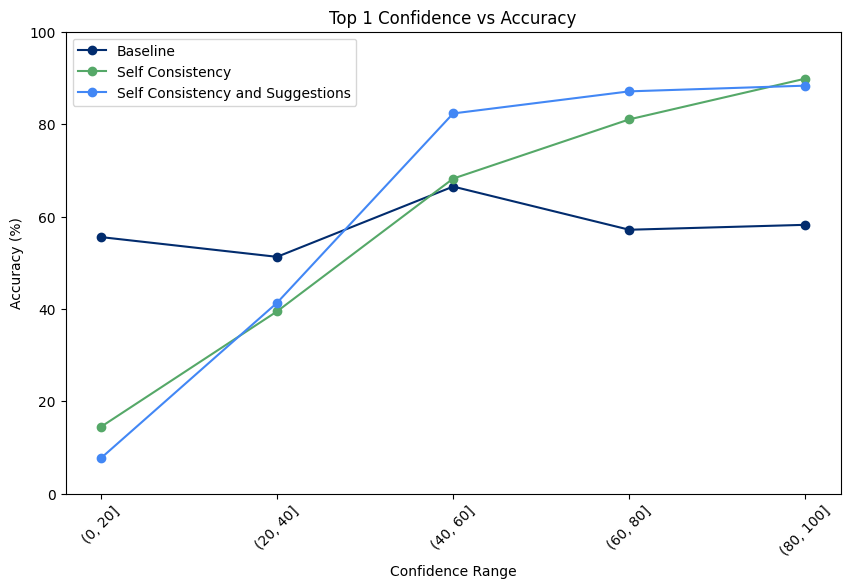

In [66]:
plt.figure(figsize=(10, 6))

color_map = {
    "Baseline": "#022c6e",
    "Self Consistency": "#55A868",
    "Self Consistency and Suggestions": "#4287f5"
}

for method in confidence_ranges["method"].unique():
    subset = confidence_ranges[confidence_ranges["method"] == method]
    
    plt.plot(
        subset["confidence_ranges"].astype(str),
        subset["accuracy_percent"],
        marker='o',
        label=method,
        color=color_map.get(method)

    )

plt.xlabel("Confidence Range")
plt.ylabel("Accuracy (%)")
plt.title("Top 1 Confidence vs Accuracy")
plt.ylim(0, 100)
plt.legend()
plt.xticks(rotation=45)

plt.show()

### Guess accuracy - all data

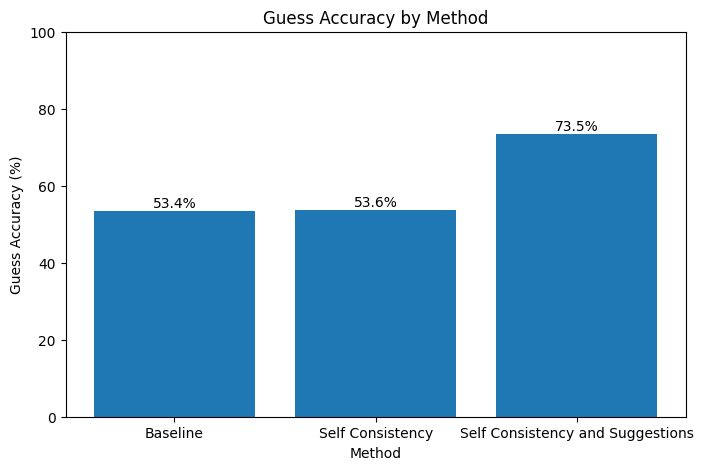

In [48]:
accuracy_by_method = (all_df.groupby("method")["correct1"].mean().mul(100).reset_index(name="accuracy_percent"))

plt.figure(figsize=(8, 5))
plt.bar(accuracy_by_method["method"], accuracy_by_method["accuracy_percent"])

plt.xlabel("Method")
plt.ylabel("Guess Accuracy (%)")
plt.title("Guess Accuracy by Method")
plt.ylim(0, 100)

for i, v in enumerate(accuracy_by_method["accuracy_percent"]):
    plt.text(i, v + 1, f"{v:.1f}%", ha="center")

plt.show()

In [53]:
all_df["correct1"] = all_df["guess1"] == all_df["solution"]

all_df["correct5"] = (
    (all_df["guess1"] == all_df["solution"]) |
    (all_df["guess2"] == all_df["solution"]) |
    (all_df["guess3"] == all_df["solution"]) |
    (all_df["guess4"] == all_df["solution"]) |
    (all_df["guess5"] == all_df["solution"])
)

accuracies = (all_df.groupby("method")[["correct1", "correct5"]].mean().mul(100).reset_index())

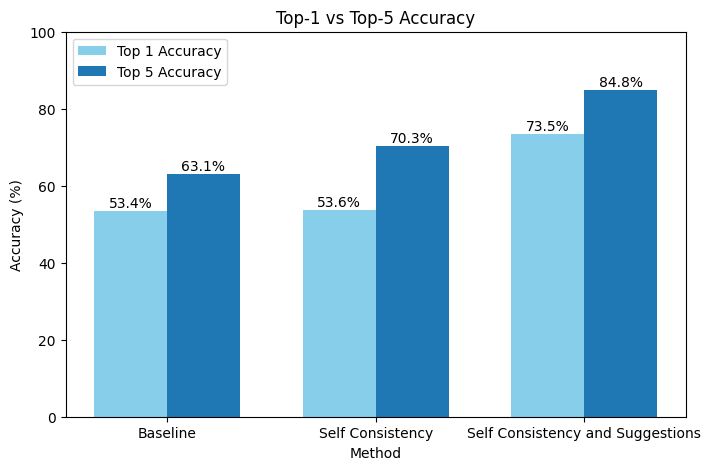

In [67]:
import matplotlib.pyplot as plt
import numpy as np

methods = accuracies["method"]
top1 = accuracies["correct1"]
top5 = accuracies["correct5"]

x = np.arange(len(methods))
width = 0.35

plt.figure(figsize=(8, 5))

plt.bar(x - width/2, top1, width, label="Top 1 Accuracy", color="skyblue")
plt.bar(x + width/2, top5, width, label="Top 5 Accuracy")

plt.xticks(x, methods)
plt.xlabel("Method")
plt.ylabel("Accuracy (%)")
plt.title("Top-1 vs Top-5 Accuracy")
plt.ylim(0, 100)
plt.legend()

# Add labels
for i in range(len(methods)):
    plt.text(x[i] - width/2, top1[i] + 1, f"{top1[i]:.1f}%", ha="center")
    plt.text(x[i] + width/2, top5[i] + 1, f"{top5[i]:.1f}%", ha="center")

plt.show()